# Phase 2 — NCAA MBB Endgame Scoring Analysis

**Goal:** Compute margin-conditioned scoring rates (points per minute) in the final 10/5/3 minutes
of regulation, stratified by home/away and opponent defensive strength.  
Produces **Tables A, B, C** and visualizations from `task.txt`.

### Methodology
- **Snapshot bucketing**: At the entry of each time window (e.g., 3:00 remaining),
  capture the score margin and lock the game into one bucket for that window.
- **PPM** = Total points scored in window / (Games in bucket × Window minutes)
- This avoids the "margin migration" problem where events shift between buckets
  during the window, artificially inflating blowout PPM.

---

## 0 — Setup & Load Data

In [70]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

SEASON = 2024
DATA_DIR = os.path.join(os.getcwd(), 'data')

# Load cached parquets
pbp       = pq.read_table(os.path.join(DATA_DIR, f'pbp_{SEASON}.parquet')).to_pandas()
team_box  = pq.read_table(os.path.join(DATA_DIR, f'team_box_{SEASON}.parquet')).to_pandas()
schedule  = pq.read_table(os.path.join(DATA_DIR, f'schedule_{SEASON}.parquet')).to_pandas()

print(f'PBP:      {pbp.shape[0]:>10,} rows x {pbp.shape[1]} cols  ({pbp["game_id"].nunique():,} games)')
print(f'Team Box: {team_box.shape[0]:>10,} rows x {team_box.shape[1]} cols  ({team_box["game_id"].nunique():,} games)')
print(f'Schedule: {schedule.shape[0]:>10,} rows x {schedule.shape[1]} cols  ({schedule["game_id"].nunique():,} games)')

PBP:       2,004,997 rows x 56 cols  (6,151 games)
Team Box:     12,480 rows x 57 cols  (6,240 games)
Schedule:      6,249 rows x 84 cols  (6,249 games)


---
## 1 — Prepare Regulation Data & Margin Buckets

In [71]:
# ── Filter to regulation only ──
reg = pbp[pbp['period_number'].isin([1, 2])].copy()
print(f'Regulation events: {len(reg):,} / {len(pbp):,} total ({len(reg)/len(pbp)*100:.1f}%)')

# ── Convert numeric columns ──
reg['home_score'] = pd.to_numeric(reg['home_score'], errors='coerce').fillna(0).astype(int)
reg['away_score'] = pd.to_numeric(reg['away_score'], errors='coerce').fillna(0).astype(int)
reg['score_value'] = pd.to_numeric(reg['score_value'], errors='coerce').fillna(0).astype(int)
reg['secs_remaining'] = pd.to_numeric(reg['end_game_seconds_remaining'], errors='coerce')

# ── Margin (home perspective) ──
reg['margin'] = reg['home_score'] - reg['away_score']

# ── Sort by game + sequence ──
reg = reg.sort_values(['game_id', 'sequence_number']).reset_index(drop=True)

# ── Scorer identity ──
reg['scorer_is_home'] = reg['team_id'] == reg['home_team_id']
reg['scorer_venue'] = np.where(reg['scorer_is_home'], 'Home', 'Away')

n_games = reg['game_id'].nunique()
print(f'Total regulation games: {n_games:,}')
print(f'secs_remaining range: {reg["secs_remaining"].min():.0f} to {reg["secs_remaining"].max():.0f}')

Regulation events: 1,985,901 / 2,004,997 total (99.0%)
Total regulation games: 6,151
secs_remaining range: 0 to 2400


In [72]:
# ── Margin bucket mapping ──
def margin_bucket(m):
    """Map a numeric margin (home - away) to task.txt buckets."""
    if pd.isna(m): return None
    m = int(m)
    if   m > 15:            return 'Leading >15'
    elif 10 <= m <= 15:     return 'Leading 10-15'
    elif 5  <= m <= 9:      return 'Leading 5-9'
    elif 1  <= m <= 4:      return 'Leading 1-4'
    elif m == 0:            return 'Tied'
    elif -4 <= m <= -1:     return 'Trailing 1-4'
    elif -9 <= m <= -5:     return 'Trailing 5-9'
    elif -15 <= m <= -10:   return 'Trailing 10-15'
    else:                   return 'Trailing >15'

BUCKET_ORDER = [
    'Leading >15', 'Leading 10-15', 'Leading 5-9', 'Leading 1-4',
    'Tied',
    'Trailing 1-4', 'Trailing 5-9', 'Trailing 10-15', 'Trailing >15'
]

print('Margin bucket function ready.')

Margin bucket function ready.


---
## 2 — Snapshot-Based Entry Margin & PPM

For each game × window, we take a **snapshot of the margin** at the entry of the window,
lock the game into that bucket, and then count all points scored within the window.

$$\text{PPM}_{\text{bucket}} = \frac{\sum \text{points in window for games in this bucket}}{\text{games in bucket} \times \text{window minutes}}$$

In [73]:
# ── Get entry margin for each game at each window boundary ──
def get_entry_margins(reg_df, window_secs):
    """
    For each game, find the margin at the entry of the time window.
    Entry = the last PBP event at or above the window boundary.
    """
    # Get events at or above the window boundary
    pre_window = reg_df[reg_df['secs_remaining'] >= window_secs]
    # Take the last event per game (closest to the window entry)
    entry_events = pre_window.groupby('game_id').last()
    return entry_events['margin']

# Compute entry margins for all three windows
entry_10 = get_entry_margins(reg, 600)
entry_5  = get_entry_margins(reg, 300)
entry_3  = get_entry_margins(reg, 180)

# Map to buckets
entry_bucket_10 = entry_10.apply(margin_bucket)
entry_bucket_5  = entry_5.apply(margin_bucket)
entry_bucket_3  = entry_3.apply(margin_bucket)

print(f'Games with entry data: F10={len(entry_10):,}  F5={len(entry_5):,}  F3={len(entry_3):,}')

# Show the entry snapshot distribution for Final 3 min
print(f'\n=== Entry Margin Distribution at 3:00 remaining ===')
for b in BUCKET_ORDER:
    cnt = (entry_bucket_3 == b).sum()
    print(f'  {b:<20} {cnt:>6,} games ({100*cnt/len(entry_bucket_3):5.1f}%)')

Games with entry data: F10=6,151  F5=6,151  F3=6,151

=== Entry Margin Distribution at 3:00 remaining ===
  Leading >15           1,651 games ( 26.8%)
  Leading 10-15           816 games ( 13.3%)
  Leading 5-9             737 games ( 12.0%)
  Leading 1-4             609 games (  9.9%)
  Tied                    498 games (  8.1%)
  Trailing 1-4            495 games (  8.0%)
  Trailing 5-9            539 games (  8.8%)
  Trailing 10-15          418 games (  6.8%)
  Trailing >15            388 games (  6.3%)


In [74]:
# ── PPM Computation Function (snapshot-based) ──
def compute_snapshot_ppm(reg_df, entry_buckets, window_secs, window_label):
    """
    Compute PPM by entry-margin bucket.
    Each game is locked into ONE bucket based on its margin at window entry.
    All points scored in the window count toward that bucket's PPM.
    """
    window_mins = window_secs / 60
    
    # Get all scoring events inside the window
    scoring = reg_df[(reg_df['scoring_play'] == True) & (reg_df['secs_remaining'] <= window_secs)].copy()
    
    # Map each event's game to its entry bucket
    scoring['entry_bucket'] = scoring['game_id'].map(entry_buckets)
    scoring = scoring.dropna(subset=['entry_bucket'])
    
    # Points and games per bucket
    pts_by_bucket = scoring.groupby('entry_bucket')['score_value'].sum()
    games_by_bucket = entry_buckets.value_counts()
    
    rows = []
    for b in BUCKET_ORDER:
        pts = pts_by_bucket.get(b, 0)
        n_g = games_by_bucket.get(b, 0)
        ppm = pts / (n_g * window_mins) if n_g > 0 else 0
        rows.append({
            'Window': window_label,
            'Margin Bucket': b,
            'Games': n_g,
            'Total Pts': int(pts),
            'PPM': round(ppm, 3),
        })
    return rows, scoring

print('Snapshot PPM computation ready.')

Snapshot PPM computation ready.


In [75]:
# ── Compute PPM for all three windows ──
rows_10, scoring_10 = compute_snapshot_ppm(reg, entry_bucket_10, 600, 'Final 10 min')
rows_5,  scoring_5  = compute_snapshot_ppm(reg, entry_bucket_5,  300, 'Final 5 min')
rows_3,  scoring_3  = compute_snapshot_ppm(reg, entry_bucket_3,  180, 'Final 3 min')

# Keep scoring_3 with entry info for later use in Tables B and C
scoring_all = {
    'Final 10 min': scoring_10,
    'Final 5 min':  scoring_5,
    'Final 3 min':  scoring_3,
}

entry_buckets_all = {
    'Final 10 min': entry_bucket_10,
    'Final 5 min':  entry_bucket_5,
    'Final 3 min':  entry_bucket_3,
}

print('PPM computed for all windows.')

PPM computed for all windows.


---
## 3 — Foul-Game Tagging

Identify foul and free-throw events from `type_text` to quantify endgame foul intensity.

In [76]:
# ── Tag foul and FT events ──
reg['type_text_lower'] = reg['type_text'].astype(str).str.lower()

reg['is_foul'] = reg['type_text_lower'].str.contains('foul', na=False)
reg['is_ft'] = (
    reg['type_text_lower'].str.contains('free throw', na=False) |
    reg['type_text_lower'].str.contains('freethrow', na=False)
)
reg['is_foul_or_ft'] = reg['is_foul'] | reg['is_ft']

# ── Foul-game intensity: rolling foul/FT rate in the last 60s of game clock ──
def foul_rate_last_60(group):
    secs = group['secs_remaining'].values
    foul_flag = group['is_foul_or_ft'].values.astype(int)
    rates = np.zeros(len(group))
    for i in range(len(group)):
        if np.isnan(secs[i]):
            continue
        window_mask = (secs >= secs[i]) & (secs <= secs[i] + 60)
        rates[i] = foul_flag[window_mask].sum()
    return pd.Series(rates, index=group.index)

final10 = reg[reg['secs_remaining'] <= 600].copy()
print(f'Computing foul intensity for {len(final10):,} final-10 events...')

final10['foul_rate_60s'] = final10.groupby('game_id', group_keys=False).apply(foul_rate_last_60)
final10['in_foul_game'] = (final10['foul_rate_60s'] >= 3) & (final10['margin'].abs() <= 9)

print(f'Events flagged as in_foul_game: {final10["in_foul_game"].sum():,} ({100*final10["in_foul_game"].mean():.1f}%)')

print('\n=== Foul/FT Event Types (final 10 min) ===')
print(final10[final10['is_foul_or_ft']]['type_text'].value_counts().head(15).to_string())

Computing foul intensity for 557,906 final-10 events...
Events flagged as in_foul_game: 153,359 (27.5%)

=== Foul/FT Event Types (final 10 min) ===
type_text
MadeFreeThrow     93746
PersonalFoul      63880
Technical Foul      698


---
## 4 — Defensive Efficiency & Quartiles

$$\text{Possessions} \approx \text{FGA} - \text{OR} + \text{TO} + 0.475 \cdot \text{FTA}$$  
$$\text{Def. Efficiency} = \frac{\text{Opp. Score}}{\text{Possessions}} \times 100$$

Teams with < 10 games excluded from quartile assignment.

In [77]:
tb = team_box.copy()

for col in ['field_goals_attempted', 'offensive_rebounds', 'turnovers',
            'free_throws_attempted', 'team_score', 'opponent_team_score']:
    tb[col] = pd.to_numeric(tb[col], errors='coerce')

tb['possessions'] = (
    tb['field_goals_attempted']
    - tb['offensive_rebounds']
    + tb['turnovers']
    + 0.475 * tb['free_throws_attempted']
)

# Season-level defense
team_def = tb.groupby('team_id').agg(
    total_opp_pts=('opponent_team_score', 'sum'),
    total_poss=('possessions', 'sum'),
    games=('game_id', 'nunique'),
    team_name=('team_display_name', 'first'),
).reset_index()

team_def['season_def_eff'] = np.where(
    team_def['total_poss'] > 0,
    team_def['total_opp_pts'] / team_def['total_poss'] * 100,
    np.nan
)

# Filter to stable teams
MIN_GAMES = 10
team_def_stable = team_def[team_def['games'] >= MIN_GAMES].copy()

team_def_stable['def_quartile'] = pd.qcut(
    team_def_stable['season_def_eff'],
    q=4,
    labels=['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']
)

print(f'Teams with >= {MIN_GAMES} games: {len(team_def_stable):,}')
print(f'\n=== Defense Quartile Distribution ===')
print(team_def_stable['def_quartile'].value_counts().sort_index().to_string())
print(f'\n=== Defensive Efficiency by Quartile ===')
print(team_def_stable.groupby('def_quartile')['season_def_eff'].describe()[['mean', 'min', 'max']].round(1).to_string())

Teams with >= 10 games: 362

=== Defense Quartile Distribution ===
def_quartile
Q1 (Elite)    91
Q2            90
Q3            90
Q4 (Weak)     91

=== Defensive Efficiency by Quartile ===
               mean    min    max
def_quartile                     
Q1 (Elite)     97.9   89.1  100.4
Q2            102.3  100.5  103.8
Q3            105.4  103.9  107.1
Q4 (Weak)     110.0  107.2  119.5


In [78]:
print('=== Top 10 Defenses ===')
display(team_def_stable.nsmallest(10, 'season_def_eff')[['team_name', 'season_def_eff', 'games', 'def_quartile']])

print('\n=== Bottom 10 Defenses ===')
display(team_def_stable.nlargest(10, 'season_def_eff')[['team_name', 'season_def_eff', 'games', 'def_quartile']])

=== Top 10 Defenses ===


,team_name,season_def_eff,games,def_quartile
142,Houston Cougars,89.081090,37,Q1 (Elite)
40,Iowa State Cyclones,90.272065,37,Q1 (Elite)
375,McNeese Cowboys,92.205458,34,Q1 (Elite)
478,Saint Mary's Gaels,92.457142,34,Q1 (Elite)
200,Texas A&M-Corpus Christi Islanders,93.277649,33,Q1 (Elite)
543,Merrimack Warriors,94.465106,33,Q1 (Elite)
249,Appalachian State Mountaineers,94.963759,34,Q1 (Elite)
362,Louisiana Tech Bulldogs,95.005866,32,Q1 (Elite)
373,Marist Red Foxes,95.360570,31,Q1 (Elite)
453,Seattle U Redhawks,95.525273,37,Q1 (Elite)



=== Bottom 10 Defenses ===


,team_name,season_def_eff,games,def_quartile
178,DePaul Blue Demons,119.525735,32,Q4 (Weak)
387,Mississippi Valley State Delta Devils,117.072460,31,Q4 (Weak)
301,Detroit Mercy Titans,116.260908,32,Q4 (Weak)
53,IUPUI Jaguars,115.603535,32,Q4 (Weak)
27,Georgetown Hoyas,114.961883,32,Q4 (Weak)
431,Portland Pilots,114.749614,33,Q4 (Weak)
407,North Carolina A&T Aggies,114.636361,32,Q4 (Weak)
163,Pacific Tigers,114.087811,32,Q4 (Weak)
79,Saint Louis Billikens,113.714044,33,Q4 (Weak)
77,Michigan Wolverines,113.489186,32,Q4 (Weak)


In [79]:
# ── Merge opponent defense quartile into each scoring DataFrame ──
def_lookup = team_def_stable.set_index('team_id')['def_quartile'].to_dict()

for key, s_df in scoring_all.items():
    s_df['opp_team_id'] = np.where(
        s_df['scorer_is_home'],
        s_df['away_team_id'],
        s_df['home_team_id']
    )
    s_df['opp_def_quartile'] = s_df['opp_team_id'].map(def_lookup)

matched = scoring_all['Final 3 min']['opp_def_quartile'].notna().sum()
total = len(scoring_all['Final 3 min'])
print(f'F3 scoring events with defense quartile: {matched:,} / {total:,} ({100*matched/total:.1f}%)')

F3 scoring events with defense quartile: 54,684 / 56,743 (96.4%)


---
## 5 — PPM Tables (A / B / C)

In [80]:
# ── TABLE A: PPM by Entry Margin Bucket x Window ──
table_a = pd.DataFrame(rows_10 + rows_5 + rows_3)

print(f'=== TABLE A: PPM by Entry Margin Bucket x Window ===')
print(f'    Season {SEASON}, {n_games:,} games')
print(f'    Margin = snapshot at window entry\n')

pivot_a = table_a.pivot_table(
    index='Margin Bucket',
    columns='Window',
    values='PPM',
    sort=False
).reindex(BUCKET_ORDER)[['Final 10 min', 'Final 5 min', 'Final 3 min']]
display(pivot_a)

=== TABLE A: PPM by Entry Margin Bucket x Window ===
    Season 2024, 6,151 games
    Margin = snapshot at window entry



Window,Final 10 min,Final 5 min,Final 3 min
Margin Bucket,,,
Leading >15,4.052,4.121,4.159
Leading 10-15,4.101,4.534,5.094
Leading 5-9,4.072,4.692,5.479
Leading 1-4,4.046,4.372,5.032
Tied,4.029,4.424,4.471
Trailing 1-4,4.074,4.453,5.034
Trailing 5-9,4.034,4.590,5.521
Trailing 10-15,4.119,4.719,5.308
Trailing >15,4.037,4.075,4.183


In [81]:
# Full detail Table A
print('=== TABLE A (Full Detail) ===')
display(table_a)

=== TABLE A (Full Detail) ===


,Window,Margin Bucket,Games,Total Pts,PPM
0,Final 10 min,Leading >15,1455,58954,4.052
1,Final 10 min,Leading 10-15,823,33754,4.101
2,Final 10 min,Leading 5-9,857,34894,4.072
3,Final 10 min,Leading 1-4,735,29740,4.046
4,Final 10 min,Tied,175,7051,4.029
5,Final 10 min,Trailing 1-4,693,28235,4.074
6,Final 10 min,Trailing 5-9,644,25982,4.034
7,Final 10 min,Trailing 10-15,427,17589,4.119
8,Final 10 min,Trailing >15,342,13808,4.037
9,Final 5 min,Leading >15,1588,32722,4.121


In [82]:
# ── TABLE B: PPM by Entry Margin x Home/Away Scorer ──
def table_b_rows(s_df, entry_buckets, window_secs, window_label):
    window_mins = window_secs / 60
    games_by_bucket = entry_buckets.value_counts()
    
    rows = []
    for b in BUCKET_ORDER:
        n_g = games_by_bucket.get(b, 0)
        bucket_events = s_df[s_df['entry_bucket'] == b]
        for venue in ['Home', 'Away']:
            pts = bucket_events[bucket_events['scorer_venue'] == venue]['score_value'].sum()
            # Each team gets half the games x minutes exposure
            ppm = pts / (n_g * window_mins) if n_g > 0 else 0
            rows.append({
                'Window': window_label,
                'Margin Bucket': b,
                'Venue': venue,
                'Total Pts': int(pts),
                'PPM': round(ppm, 3),
            })
    return rows

table_b_data = []
for wl, ws, eb, sd in [('Final 10 min', 600, entry_bucket_10, scoring_10),
                        ('Final 5 min',  300, entry_bucket_5,  scoring_5),
                        ('Final 3 min',  180, entry_bucket_3,  scoring_3)]:
    table_b_data += table_b_rows(sd, eb, ws, wl)

table_b = pd.DataFrame(table_b_data)

for wl in ['Final 10 min', 'Final 5 min', 'Final 3 min']:
    print(f'\n=== TABLE B: PPM by Entry Margin x Home/Away ({wl}) ===')
    tb_pivot = table_b[table_b['Window'] == wl].pivot_table(
        index='Margin Bucket',
        columns='Venue',
        values='PPM',
        sort=False
    ).reindex(BUCKET_ORDER)[['Home', 'Away']]
    tb_pivot['Home-Away Delta'] = tb_pivot['Home'] - tb_pivot['Away']
    display(tb_pivot)


=== TABLE B: PPM by Entry Margin x Home/Away (Final 10 min) ===


Venue,Home,Away,Home-Away Delta
Margin Bucket,,,
Leading >15,2.172,1.880,0.292
Leading 10-15,2.089,2.012,0.077
Leading 5-9,2.063,2.008,0.055
Leading 1-4,2.080,1.966,0.114
Tied,2.098,1.931,0.167
Trailing 1-4,2.111,1.963,0.148
Trailing 5-9,2.078,1.957,0.121
Trailing 10-15,2.162,1.958,0.204
Trailing >15,2.073,1.964,0.109



=== TABLE B: PPM by Entry Margin x Home/Away (Final 5 min) ===


Venue,Home,Away,Home-Away Delta
Margin Bucket,,,
Leading >15,2.145,1.976,0.169
Leading 10-15,2.287,2.247,0.040
Leading 5-9,2.368,2.323,0.045
Leading 1-4,2.234,2.138,0.096
Tied,2.239,2.185,0.054
Trailing 1-4,2.296,2.157,0.139
Trailing 5-9,2.396,2.194,0.202
Trailing 10-15,2.441,2.278,0.163
Trailing >15,2.131,1.945,0.186



=== TABLE B: PPM by Entry Margin x Home/Away (Final 3 min) ===


Venue,Home,Away,Home-Away Delta
Margin Bucket,,,
Leading >15,2.094,2.066,0.028
Leading 10-15,2.528,2.565,-0.037
Leading 5-9,2.802,2.677,0.125
Leading 1-4,2.648,2.384,0.264
Tied,2.263,2.207,0.056
Trailing 1-4,2.538,2.496,0.042
Trailing 5-9,2.779,2.742,0.037
Trailing 10-15,2.726,2.582,0.144
Trailing >15,2.290,1.893,0.397


In [83]:
# ── TABLE C: PPM by Entry Margin x Opponent Defense Quartile ──
def table_c_rows(s_df, entry_buckets, window_secs, window_label):
    window_mins = window_secs / 60
    games_by_bucket = entry_buckets.value_counts()
    
    s_with_def = s_df.dropna(subset=['opp_def_quartile'])
    
    rows = []
    for b in BUCKET_ORDER:
        n_g = games_by_bucket.get(b, 0)
        bucket_events = s_with_def[s_with_def['entry_bucket'] == b]
        for q in ['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']:
            pts = bucket_events[bucket_events['opp_def_quartile'] == q]['score_value'].sum()
            # Approximate: each quartile represents ~1/4 of games in bucket
            ppm = pts / (n_g * window_mins) if n_g > 0 else 0
            rows.append({
                'Window': window_label,
                'Margin Bucket': b,
                'Opp Defense': q,
                'Total Pts': int(pts),
                'PPM': round(ppm, 3),
            })
    return rows

table_c_data = []
for wl, ws, eb, sd in [('Final 10 min', 600, entry_bucket_10, scoring_10),
                        ('Final 5 min',  300, entry_bucket_5,  scoring_5),
                        ('Final 3 min',  180, entry_bucket_3,  scoring_3)]:
    table_c_data += table_c_rows(sd, eb, ws, wl)

table_c = pd.DataFrame(table_c_data)

for wl in ['Final 3 min', 'Final 5 min']:
    print(f'\n=== TABLE C: PPM by Entry Margin x Opp Defense Quartile ({wl}) ===')
    tc_pivot = table_c[table_c['Window'] == wl].pivot_table(
        index='Margin Bucket',
        columns='Opp Defense',
        values='PPM',
        sort=False
    ).reindex(BUCKET_ORDER)[['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']]
    display(tc_pivot)


=== TABLE C: PPM by Entry Margin x Opp Defense Quartile (Final 3 min) ===


Opp Defense,Q1 (Elite),Q2,Q3,Q4 (Weak)
Margin Bucket,,,,
Leading >15,0.951,0.841,0.829,0.902
Leading 10-15,1.261,1.291,1.371,1.073
Leading 5-9,1.338,1.356,1.496,1.237
Leading 1-4,1.153,1.279,1.263,1.292
Tied,1.089,1.157,1.122,1.084
Trailing 1-4,1.325,1.240,1.258,1.205
Trailing 5-9,1.202,1.477,1.495,1.340
Trailing 10-15,1.278,1.276,1.353,1.392
Trailing >15,1.051,0.987,0.900,1.216



=== TABLE C: PPM by Entry Margin x Opp Defense Quartile (Final 5 min) ===


Opp Defense,Q1 (Elite),Q2,Q3,Q4 (Weak)
Margin Bucket,,,,
Leading >15,0.897,0.842,0.822,0.905
Leading 10-15,1.122,1.049,1.220,1.012
Leading 5-9,1.232,1.197,1.177,1.046
Leading 1-4,0.969,1.123,1.180,1.058
Tied,1.083,1.083,1.159,1.082
Trailing 1-4,1.076,1.125,1.106,1.131
Trailing 5-9,1.168,1.121,1.126,1.169
Trailing 10-15,1.134,1.152,1.236,1.197
Trailing >15,0.920,0.965,0.924,1.235


---
## 6 — Visualizations

In [84]:
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'font.size': 11,
    'axes.titlesize': 14,
    'figure.titlesize': 16,
})

COLORS = {
    'Final 10 min': '#4cc9f0',
    'Final 5 min':  '#f72585',
    'Final 3 min':  '#7209b7',
}

print('Plot style configured.')

Plot style configured.


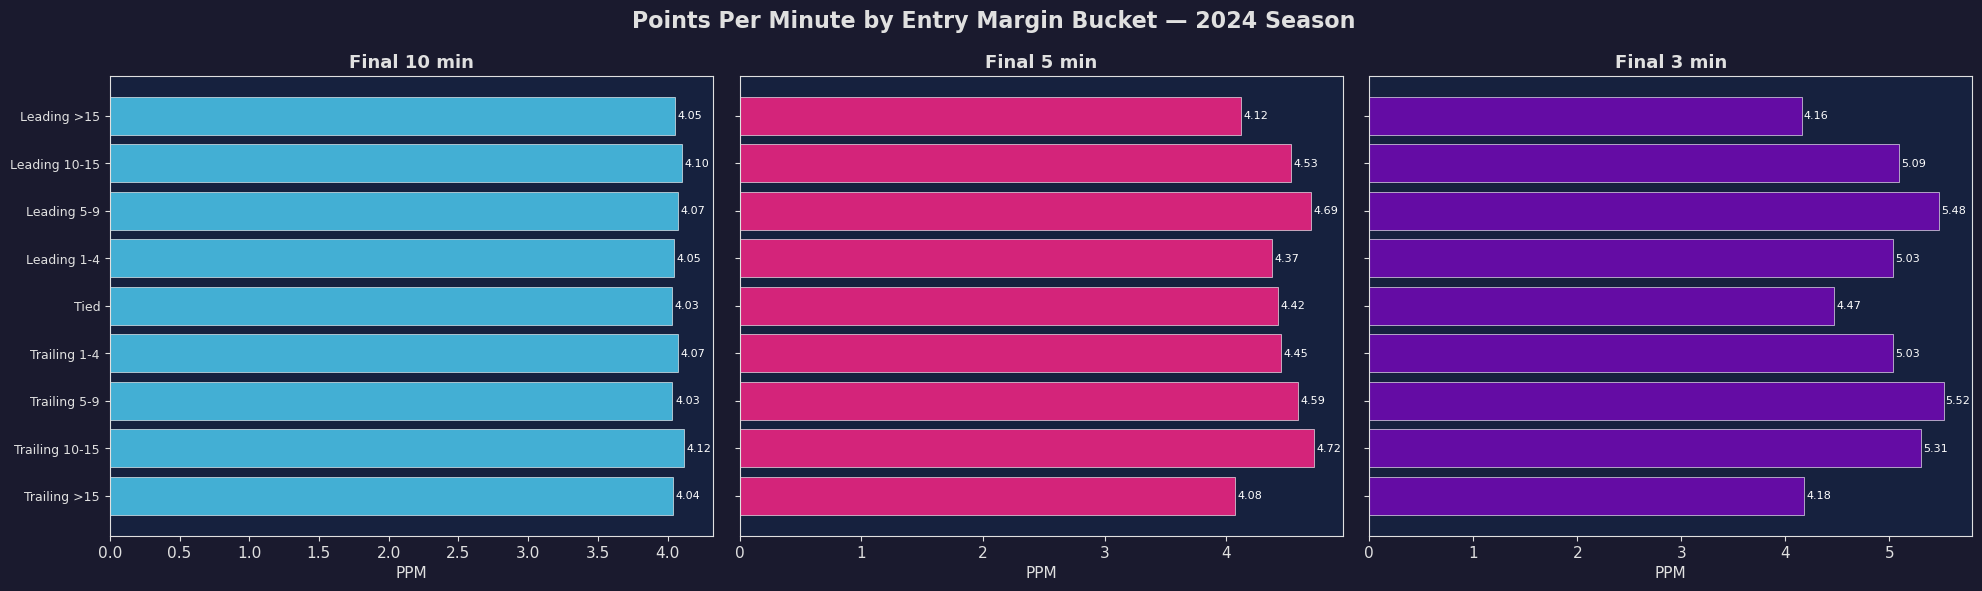

Saved: viz_table_a_ppm.png


In [85]:
# ── VIZ 1: PPM by Entry Margin Bucket for each window ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle(f'Points Per Minute by Entry Margin Bucket — {SEASON} Season',
             fontsize=16, fontweight='bold')

for ax, wl in zip(axes, ['Final 10 min', 'Final 5 min', 'Final 3 min']):
    data = table_a[table_a['Window'] == wl].set_index('Margin Bucket').reindex(BUCKET_ORDER)
    
    bars = ax.barh(
        range(len(BUCKET_ORDER)),
        data['PPM'].values,
        color=COLORS[wl],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_yticks(range(len(BUCKET_ORDER)))
    ax.set_yticklabels(BUCKET_ORDER, fontsize=9)
    ax.set_xlabel('PPM')
    ax.set_title(wl, fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    
    for i, v in enumerate(data['PPM'].values):
        if not np.isnan(v):
            ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_table_a_ppm.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_table_a_ppm.png')

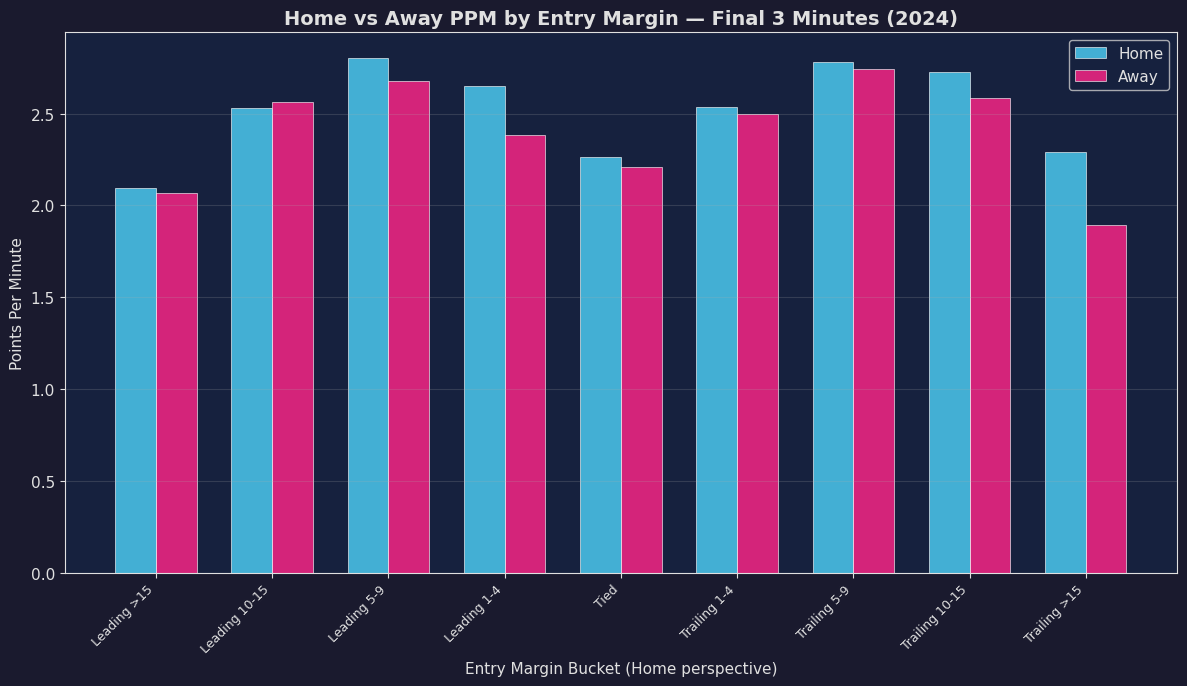

Saved: viz_table_b_home_away.png


In [86]:
# ── VIZ 2: Home vs Away PPM (Final 3 min) ──
fig, ax = plt.subplots(figsize=(12, 7))

tb_f3 = table_b[table_b['Window'] == 'Final 3 min']

x = np.arange(len(BUCKET_ORDER))
width = 0.35

home_ppm = [tb_f3[(tb_f3['Margin Bucket'] == b) & (tb_f3['Venue'] == 'Home')]['PPM'].values[0] for b in BUCKET_ORDER]
away_ppm = [tb_f3[(tb_f3['Margin Bucket'] == b) & (tb_f3['Venue'] == 'Away')]['PPM'].values[0] for b in BUCKET_ORDER]

bars1 = ax.bar(x - width/2, home_ppm, width, label='Home', color='#4cc9f0', alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, away_ppm, width, label='Away', color='#f72585', alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Entry Margin Bucket (Home perspective)')
ax.set_ylabel('Points Per Minute')
ax.set_title(f'Home vs Away PPM by Entry Margin — Final 3 Minutes ({SEASON})', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(BUCKET_ORDER, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_table_b_home_away.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_table_b_home_away.png')

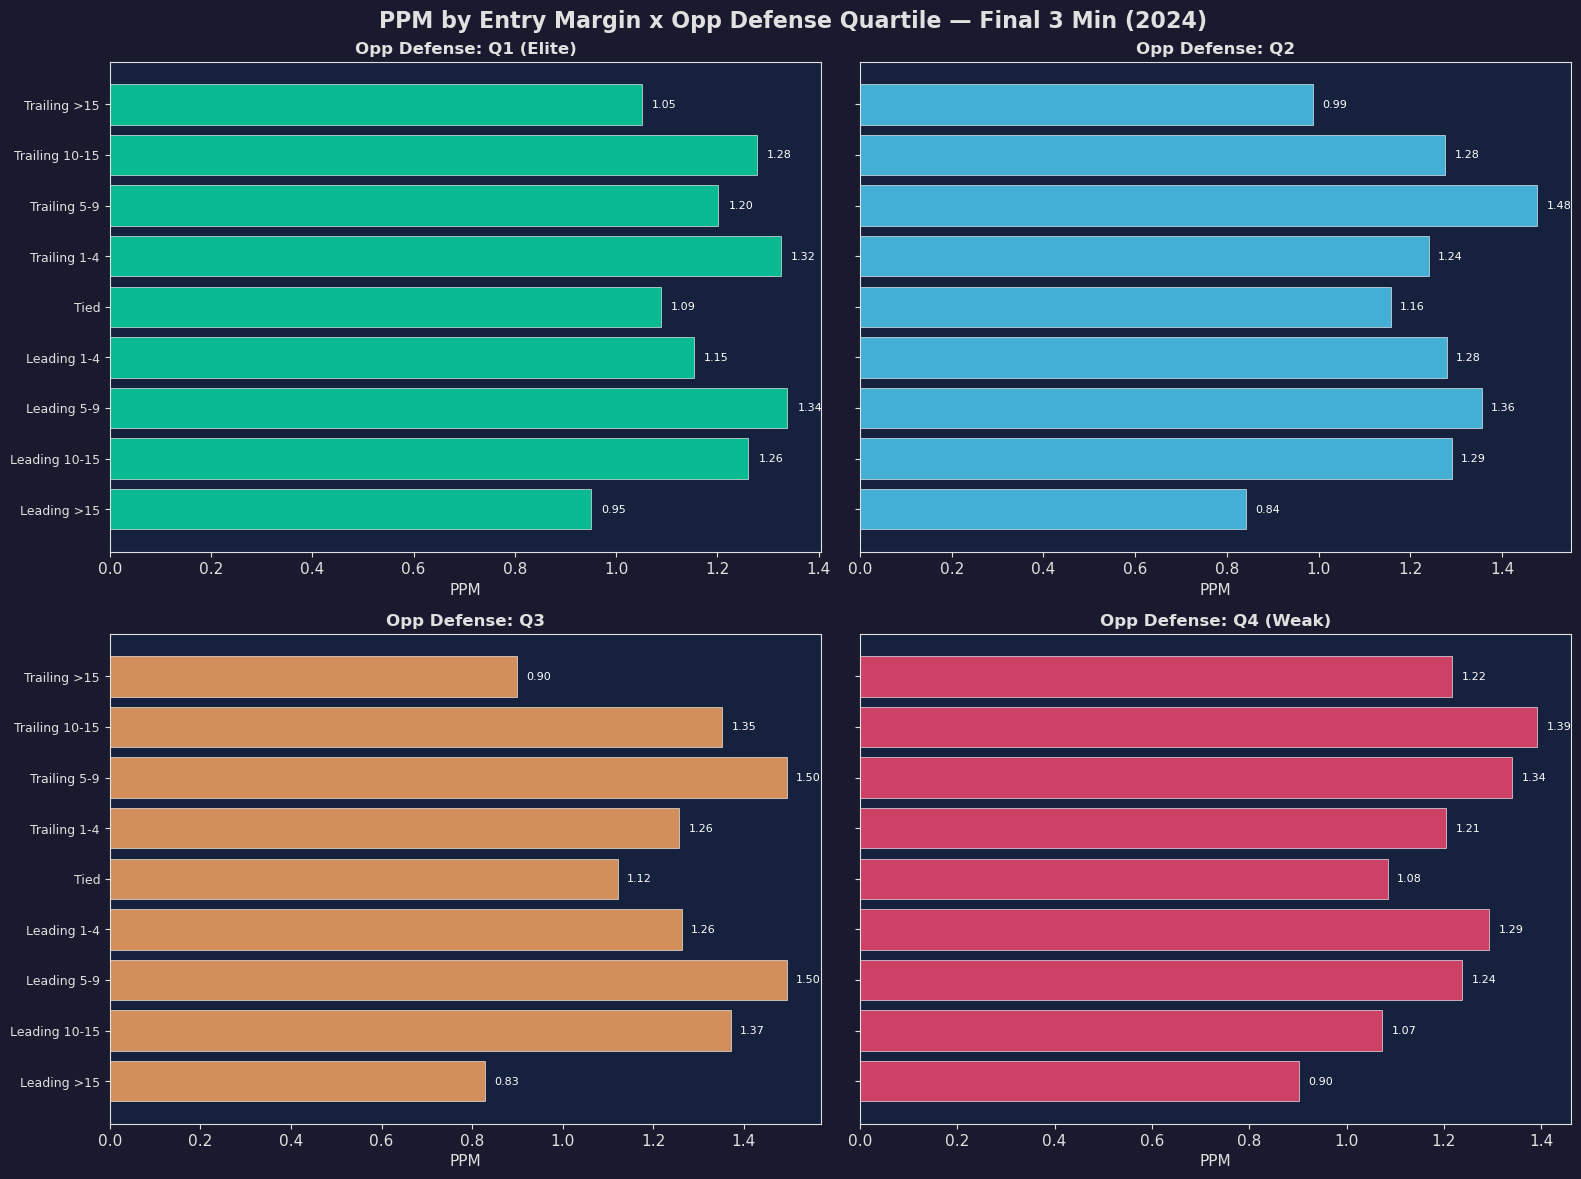

Saved: viz_table_c_defense.png


In [87]:
# ── VIZ 3: Defense Quartile Faceted (Final 3 min) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
fig.suptitle(f'PPM by Entry Margin x Opp Defense Quartile — Final 3 Min ({SEASON})',
             fontsize=16, fontweight='bold')

q_colors = {'Q1 (Elite)': '#06d6a0', 'Q2': '#4cc9f0', 'Q3': '#f4a261', 'Q4 (Weak)': '#ef476f'}

tc_f3 = table_c[table_c['Window'] == 'Final 3 min']

for ax, q in zip(axes.flat, ['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']):
    q_data = tc_f3[tc_f3['Opp Defense'] == q].set_index('Margin Bucket').reindex(BUCKET_ORDER)
    
    ax.barh(
        range(len(BUCKET_ORDER)),
        q_data['PPM'].values,
        color=q_colors[q],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_yticks(range(len(BUCKET_ORDER)))
    ax.set_yticklabels(BUCKET_ORDER, fontsize=9)
    ax.set_xlabel('PPM')
    ax.set_title(f'Opp Defense: {q}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    
    for i, v in enumerate(q_data['PPM'].values):
        if not np.isnan(v):
            ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_table_c_defense.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_table_c_defense.png')

---
## 7 — Robustness Checks

In [88]:
# ── 7a: Alternate margin bins (possession-based) ──
def possession_bucket(m):
    if pd.isna(m): return None
    m = int(m)
    am = abs(m)
    prefix = 'Leading' if m > 0 else ('Trailing' if m < 0 else 'Tied')
    if m == 0:        return 'Tied'
    elif am <= 3:     return f'{prefix} 1-poss (1-3)'
    elif am <= 6:     return f'{prefix} 2-poss (4-6)'
    elif am <= 9:     return f'{prefix} 3-poss (7-9)'
    else:             return f'{prefix} >3-poss (10+)'

POSS_ORDER = [
    'Leading >3-poss (10+)', 'Leading 3-poss (7-9)', 'Leading 2-poss (4-6)', 'Leading 1-poss (1-3)',
    'Tied',
    'Trailing 1-poss (1-3)', 'Trailing 2-poss (4-6)', 'Trailing 3-poss (7-9)', 'Trailing >3-poss (10+)'
]

# Apply alt buckets using the same snapshot at 180s
alt_entry_buckets_3 = entry_3.apply(possession_bucket)

alt_scoring_3 = reg[(reg['scoring_play'] == True) & (reg['secs_remaining'] <= 180)].copy()
alt_scoring_3['entry_bucket'] = alt_scoring_3['game_id'].map(alt_entry_buckets_3)
alt_scoring_3 = alt_scoring_3.dropna(subset=['entry_bucket'])

alt_pts = alt_scoring_3.groupby('entry_bucket')['score_value'].sum()
alt_games = alt_entry_buckets_3.value_counts()

alt_rows = []
for b in POSS_ORDER:
    pts = alt_pts.get(b, 0)
    n_g = alt_games.get(b, 0)
    ppm = pts / (n_g * 3) if n_g > 0 else 0
    alt_rows.append({'Poss Bucket': b, 'Games': n_g, 'Total Pts': int(pts), 'PPM': round(ppm, 3)})

print('=== Robustness: Alternate Margin Bins (Possession-Based), Final 3 Min ===')
display(pd.DataFrame(alt_rows))

=== Robustness: Alternate Margin Bins (Possession-Based), Final 3 Min ===


,Poss Bucket,Games,Total Pts,PPM
0,Leading >3-poss (10+),2467,33071,4.468
1,Leading 3-poss (7-9),419,6924,5.508
2,Leading 2-poss (4-6),480,7705,5.351
3,Leading 1-poss (1-3),447,6678,4.980
4,Tied,498,6679,4.471
5,Trailing 1-poss (1-3),387,5823,5.016
6,Trailing 2-poss (4-6),358,5720,5.326
7,Trailing 3-poss (7-9),289,4861,5.607
8,Trailing >3-poss (10+),806,11525,4.766


In [89]:
# ── 7b: Blowout exclusions ──
blowout_games = entry_bucket_3[entry_bucket_3.isin(['Leading >15', 'Trailing >15'])].index
n_blowout = len(blowout_games)

print(f'Games entering final 3 min with |margin| > 15: {n_blowout:,} / {n_games:,} ({100*n_blowout/n_games:.1f}%)')

# PPM for non-blowout games
nb_entry_3 = entry_bucket_3[~entry_bucket_3.index.isin(blowout_games)]
nb_scoring_3 = scoring_3[~scoring_3['game_id'].isin(blowout_games)]

nb_pts = nb_scoring_3.groupby('entry_bucket')['score_value'].sum()
nb_games_by = nb_entry_3.value_counts()

nb_rows = []
for b in BUCKET_ORDER:
    if b in ['Leading >15', 'Trailing >15']:
        nb_rows.append({'Margin Bucket': b, 'PPM (No Blowout)': None})
        continue
    pts = nb_pts.get(b, 0)
    n_g = nb_games_by.get(b, 0)
    ppm = pts / (n_g * 3) if n_g > 0 else 0
    nb_rows.append({'Margin Bucket': b, 'PPM (No Blowout)': round(ppm, 3)})

nb_df = pd.DataFrame(nb_rows)
w3_full = table_a[table_a['Window'] == 'Final 3 min'][['Margin Bucket', 'PPM']].rename(columns={'PPM': 'PPM (Full)'})
comparison = w3_full.merge(nb_df, on='Margin Bucket')

print(f'\n=== Robustness: Full vs No-Blowout PPM (Final 3 Min) ===')
print(f'    Games: {n_games:,} (full) vs {len(nb_entry_3):,} (excl blowouts)\n')
display(comparison)

Games entering final 3 min with |margin| > 15: 2,039 / 6,151 (33.1%)

=== Robustness: Full vs No-Blowout PPM (Final 3 Min) ===
    Games: 6,151 (full) vs 4,112 (excl blowouts)



,Margin Bucket,PPM (Full),PPM (No Blowout)
0,Leading >15,4.159,NaN
1,Leading 10-15,5.094,5.094
2,Leading 5-9,5.479,5.479
3,Leading 1-4,5.032,5.032
4,Tied,4.471,4.471
5,Trailing 1-4,5.034,5.034
6,Trailing 5-9,5.521,5.521
7,Trailing 10-15,5.308,5.308
8,Trailing >15,4.183,NaN


In [90]:
# ── 7c: OT exclusion verification ──
ot_events = pbp[pbp['period_number'] > 2]
ot_games = ot_events['game_id'].nunique()
total_games = pbp['game_id'].nunique()

print(f'Games with overtime: {ot_games:,} / {total_games:,} ({100*ot_games/total_games:.1f}%)')
print(f'OT events excluded from all analyses: {len(ot_events):,}')
print(f'OT periods present: {sorted(ot_events["period_number"].unique().tolist())}')

Games with overtime: 344 / 6,151 (5.6%)
OT events excluded from all analyses: 19,096
OT periods present: [3, 4, 5]


---
## 8 — Summary & Next Steps

In [91]:
print('='*60)
print(f'  ENDGAME SCORING ANALYSIS — {SEASON} Season Complete')
print('='*60)
print(f'\n  Games analyzed:              {n_games:,}')
print(f'  Regulation PBP events:       {len(reg):,}')
print(f'  Teams with def. efficiency:  {len(team_def_stable):,} (>={MIN_GAMES} games)')
print(f'  Games with OT (excluded):    {ot_games:,}')
print(f'\n  Methodology:')
print(f'    Margin = SNAPSHOT at window entry (not shifting during window)')
print(f'    PPM = total_pts / (games_in_bucket x window_minutes)')
print(f'    Each game belongs to ONE bucket per window')
print(f'\n  Outputs:')
print(f'    Table A: PPM by entry margin x window (10/5/3)')
print(f'    Table B: PPM by entry margin x home/away scorer')
print(f'    Table C: PPM by entry margin x opponent defense quartile')
print(f'    3 visualizations saved to data/')
print(f'    Robustness: alt bins, blowout exclusions, OT check')
print(f'\n  Next steps for 2015-2024:')
print(f'    1. Loop data pull across seasons')
print(f'    2. Add season fixed effects')
print(f'    3. Fit hierarchical NegBin model')
print(f'    4. Produce CI/CrI on PPM estimates')

  ENDGAME SCORING ANALYSIS — 2024 Season Complete

  Games analyzed:              6,151
  Regulation PBP events:       1,985,901
  Teams with def. efficiency:  362 (>=10 games)
  Games with OT (excluded):    344

  Methodology:
    Margin = SNAPSHOT at window entry (not shifting during window)
    PPM = total_pts / (games_in_bucket x window_minutes)
    Each game belongs to ONE bucket per window

  Outputs:
    Table A: PPM by entry margin x window (10/5/3)
    Table B: PPM by entry margin x home/away scorer
    Table C: PPM by entry margin x opponent defense quartile
    3 visualizations saved to data/
    Robustness: alt bins, blowout exclusions, OT check

  Next steps for 2015-2024:
    1. Loop data pull across seasons
    2. Add season fixed effects
    3. Fit hierarchical NegBin model
    4. Produce CI/CrI on PPM estimates
